In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

sns.set_theme(style="whitegrid")

# 1. Load the massive dataset
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin1')

print(f"Raw dataset shape: {df.shape}")

Raw dataset shape: (180519, 53)


In [2]:
# 2. Select only the features known at checkout, plus our target variable
features = ['Shipping Mode', 'Order Region', 'Market', 'Order Item Total', 'Order Item Quantity', 'Late_delivery_risk']
df_ml = df[features].dropna()

# 3. Machine Learning models only understand numbers, not text. 
# We use "One-Hot Encoding" to turn categories (like 'First Class') into 1s and 0s.
df_encoded = pd.get_dummies(df_ml, columns=['Shipping Mode', 'Order Region', 'Market'], drop_first=True)

# 4. Split data into X (Features) and y (Target)
X = df_encoded.drop('Late_delivery_risk', axis=1)
y = df_encoded['Late_delivery_risk']

# 5. Split into Training Data (80%) and Testing Data (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")

Training features shape: (144415, 31)


In [3]:
# 1. Initialize the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Train (Fit) the model on our historical data
print("Training the AI model... (This might take 1-2 minutes!)")
rf_model.fit(X_train, y_train)

# 3. Test the model on the 20% of data it has never seen before
y_pred = rf_model.predict(X_test)

# 4. Evaluate the results
print("\n--- Model Evaluation ---")
print(classification_report(y_test, y_pred))

Training the AI model... (This might take 1-2 minutes!)

--- Model Evaluation ---
              precision    recall  f1-score   support

           0       0.59      0.69      0.64     16307
           1       0.70      0.61      0.65     19797

    accuracy                           0.65     36104
   macro avg       0.65      0.65      0.65     36104
weighted avg       0.65      0.65      0.65     36104



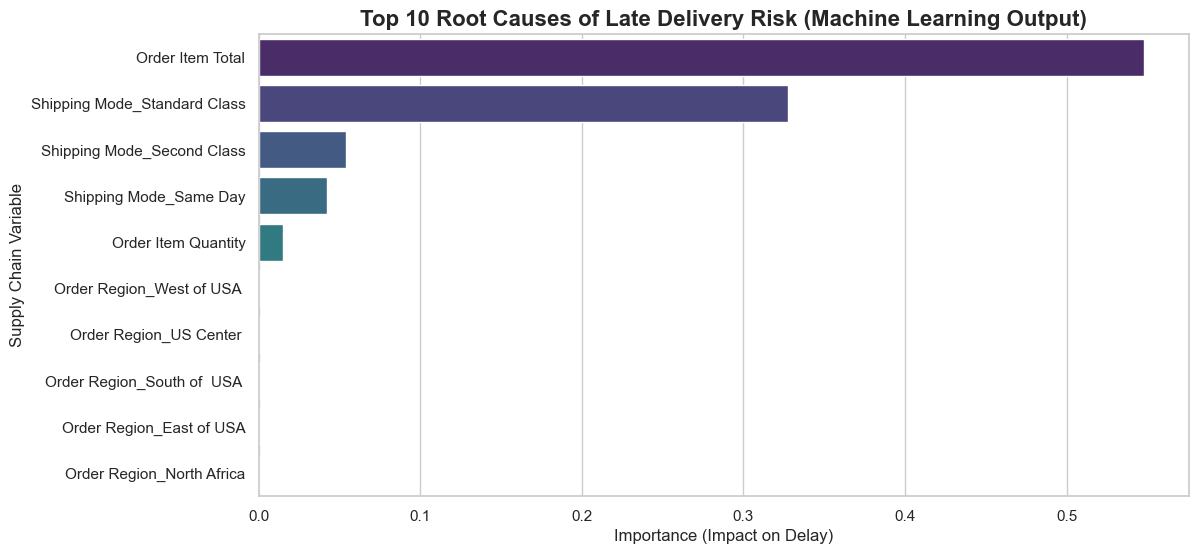

In [5]:
# Extract the importance of each feature from the model
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(10) # Get top 10 drivers

# Plot the Feature Importance
plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importances, x='Importance', y='Feature', palette='viridis', hue='Feature', legend=False)

plt.title('Top 10 Root Causes of Late Delivery Risk (Machine Learning Output)', fontsize=16, fontweight='bold')
plt.xlabel('Importance (Impact on Delay)', fontsize=12)
plt.ylabel('Supply Chain Variable', fontsize=12)

plt.show()